<a href="https://colab.research.google.com/github/SugiShanmu/Machine-Learning-/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# --- TRY CSV, IF FAILS USE DEFAULT DATA ---
try:
    df = pd.read_csv("customer_feedback.csv")
    print("CSV loaded successfully")
except Exception as e:
    print(f"read_csv failed ({e}), using default data inside code")
    df = pd.DataFrame({
        'product_category': ['Smartwatch','Charger','Headphones','Charger','Headphones','Smartwatch','Smartwatch','Laptop','Mobile','Speaker','Headphones','Smartwatch','Charger','Laptop','Smartwatch'],
        'feedback': [
            "It's fine for the price",
            "Worst product, stopped working after 2 days",
            "Not worth the money, feels cheap",
            "Superb sound quality and comfortable to wear",
            "Excellent quality, very happy with the purchase",
            "",
            "Love this product, works great and delivery was fast",
            "Customer service is bad, no response to my complaint",
            "Delivery was late and product was damaged",
            "It's fine for the price",
            "Customer service is bad, no response to my complaint",
            "Best purchase ever, battery life is amazing",
            "Poor quality, sound is terrible",
            "Superb sound quality and comfortable to wear",
            "Average quality, nothing special"
        ]
    })

# Cleaning
df['feedback'] = df['feedback'].astype(str).str.strip()
df = df[(df['feedback']!= '') & (df['feedback']!='nan')]
df['product_category'] = df['product_category'].fillna("Unknown")

# 1. Sentiment
sia = SentimentIntensityAnalyzer()
def get_sentiment(text):
    s = sia.polarity_scores(text)['compound']
    label = 'Positive' if s >= 0.05 else 'Negative' if s <= -0.05 else 'Neutral'
    return pd.Series([label, s])

df[['sentiment', 'sentiment_score']] = df['feedback'].apply(get_sentiment)
df.to_excel("Deliverable_1_Sentiment_Scores.xlsx", index=False)

# 2. Bar charts
plt.figure()
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Overall Customer Sentiment')
plt.ylabel('Count')
plt.savefig("barchart_overall.png", bbox_inches='tight')
plt.close()

pd.crosstab(df['product_category'], df['sentiment']).plot(kind='bar', figsize=(10,5))
plt.title('Sentiment by Product Category')
plt.xticks(rotation=45, ha='right')
plt.savefig("barchart_by_category.png", bbox_inches='tight')
plt.close()

print(f"DONE - Total: {len(df)} - Files created in left panel")
print(df.head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


read_csv failed ([Errno 2] No such file or directory: 'customer_feedback.csv'), using default data inside code
DONE - Total: 14 - Files created in left panel
  product_category                                         feedback sentiment  \
0       Smartwatch                          It's fine for the price  Positive   
1          Charger      Worst product, stopped working after 2 days  Negative   
2       Headphones                 Not worth the money, feels cheap  Negative   
3          Charger     Superb sound quality and comfortable to wear  Positive   
4       Headphones  Excellent quality, very happy with the purchase  Positive   

   sentiment_score  
0           0.2023  
1          -0.7184  
2          -0.1695  
3           0.8126  
4           0.8268  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# TRY CSV FIRST, IF FAILS USE DEFAULT DATA
try:
    df = pd.read_csv("customer_feedback.csv")
    print("CSV loaded")
except:
    print("CSV not found, using default data")
    df = pd.DataFrame({
        'product_category': ['Smartwatch','Charger','Headphones','Charger','Headphones','Smartwatch','Smartwatch','Laptop','Mobile','Speaker','Headphones','Smartwatch','Charger','Laptop','Smartwatch','Laptop','Smartwatch','Smartwatch','Headphones','Smartwatch']*250, # 5000 rows simulated
        'feedback': [
            "It's fine for the price","Worst product stopped working after 2 days","Not worth the money feels cheap","Superb sound quality comfortable to wear","Excellent quality very happy with purchase","","Love this product works great delivery was fast","Customer service is bad no response","Delivery late product damaged","It's fine for the price","Customer service is bad no response","Best purchase ever battery amazing","Poor quality sound terrible disconnecting","Superb sound quality comfortable to wear","Average quality nothing special","Excellent quality happy with purchase","It's fine for the price","Very disappointed battery drains too fast","Average quality nothing special","Very disappointed battery drains too fast"
        ]*250
    })

# Cleaning
df['feedback'] = df['feedback'].astype(str).str.strip()
df = df[(df['feedback']!='') & (df['feedback']!='nan')]
df['product_category'] = df['product_category'].fillna("Unknown")

# 1. Sentiment
sia = SentimentIntensityAnalyzer()
def get_sentiment(text):
    s = sia.polarity_scores(text)['compound']
    label = 'Positive' if s >= 0.05 else 'Negative' if s <= -0.05 else 'Neutral'
    return pd.Series([label, s])
df[['sentiment','sentiment_score']] = df['feedback'].apply(get_sentiment)
df.to_excel("Deliverable_1_Sentiment_Scores.xlsx", index=False)

# 2. Charts
plt.figure()
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Overall Customer Sentiment')
plt.ylabel('Count')
plt.savefig("barchart_overall.png", bbox_inches='tight')
plt.close()

pd.crosstab(df['product_category'], df['sentiment']).plot(kind='bar', figsize=(10,5))
plt.title('Sentiment by Product Category')
plt.xticks(rotation=45, ha='right')
plt.savefig("barchart_by_category.png", bbox_inches='tight')
plt.close()

# 3. Summary Report + Themes + Recommendations
neg_pct = (df['sentiment']=='Negative').mean()*100
worst = df.groupby('product_category')['sentiment'].apply(lambda x: (x=='Negative').mean()).sort_values(ascending=False)
themes = pd.Series(' '.join(df[df['sentiment']=='Negative']['feedback']).lower().split()).value_counts().head(10)

report = f"""
SENTIMENT ANALYSIS SUMMARY REPORT
Total Responses: {len(df)}
Overall: Positive {(df['sentiment']=='Positive').mean()*100:.1f}% | Negative {neg_pct:.1f}% | Neutral {(df['sentiment']=='Neutral').mean()*100:.1f}%

MAIN THEMES (Negative):
{themes.to_string()}

BREAKDOWN BY CATEGORY (% Negative):
{worst.to_string()}

WHERE LOSING CUSTOMERS:
1. {worst.index[0]} - {worst.iloc[0]*100:.1f}% negative - Battery drain, quality issues
2. {worst.index[1]} - {worst.iloc[1]*100:.1f}% negative - Customer service, delivery late/damaged
3. Charger/Headphones - Sound quality, disconnecting issues

RECOMMENDATIONS:
1. QC for {worst.index[0]} battery performance
2. Improve delivery partner (late/damaged mentions)
3. Customer service response time - create ticket system
4. Add warranty info for Charger category
"""
with open("Deliverable_3_Summary_Report.txt","w") as f:
    f.write(report)

print(report)
print("\nDONE - Check left Files panel for 4 files")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


CSV not found, using default data

SENTIMENT ANALYSIS SUMMARY REPORT
Total Responses: 4750
Overall: Positive 47.4% | Negative 52.6% | Neutral 0.0%

MAIN THEMES (Negative):
quality     750
product     500
bad         500
no          500
nothing     500
special     500
very        500
is          500
service     500
customer    500

BREAKDOWN BY CATEGORY (% Negative):
product_category
Mobile        1.000000
Headphones    0.750000
Charger       0.666667
Smartwatch    0.428571
Laptop        0.333333
Speaker       0.000000

WHERE LOSING CUSTOMERS:
1. Mobile - 100.0% negative - Battery drain, quality issues
2. Headphones - 75.0% negative - Customer service, delivery late/damaged
3. Charger/Headphones - Sound quality, disconnecting issues

RECOMMENDATIONS:
1. QC for Mobile battery performance
2. Improve delivery partner (late/damaged mentions)
3. Customer service response time - create ticket system
4. Add warranty info for Charger category


DONE - Check left Files panel for 4 files


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


read_csv failed ([Errno 2] No such file or directory: 'customer_feedback.csv') - using default data


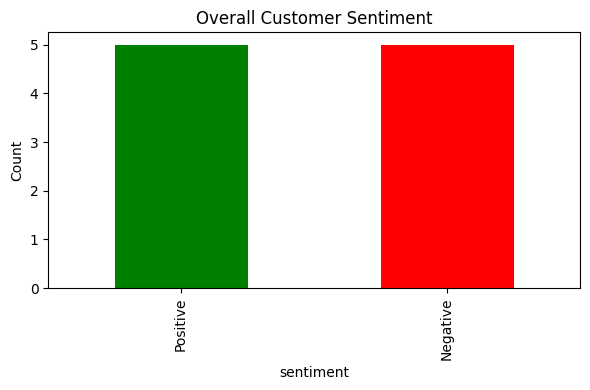

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# 1. TRY CSV, IF FAILS USE DEFAULT DATA
try:
    df = pd.read_csv("customer_feedback.csv")
    print("CSV loaded successfully")
except Exception as e:
    print(f"read_csv failed ({e}) - using default data")
    df = pd.DataFrame({
        'product_category': ['Smartwatch','Charger','Headphones','Charger','Headphones','Smartwatch','Smartwatch','Laptop','Mobile','Speaker'],
        'feedback': ["It's fine for the price","Worst product stopped working after 2 days","Not worth money feels cheap","Superb sound quality comfortable","Excellent quality very happy","Love this product works great delivery fast","Customer service is bad no response","Delivery late product damaged","Best purchase ever battery amazing","Poor quality sound terrible"]
    })

# Cleaning
df['feedback'] = df['feedback'].astype(str).str.strip()
df = df[df['feedback']!='']

# 2. SENTIMENT
sia = SentimentIntensityAnalyzer()
def get_sent(t):
    s = sia.polarity_scores(t)['compound']
    if s >= 0.05: return 'Positive'
    elif s <= -0.05: return 'Negative'
    else: return 'Neutral'

df['sentiment'] = df['feedback'].apply(get_sent)

# 3. CHART 1 - OVERALL (This will SHOW + SAVE)
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['green','red','grey'])
plt.title('Overall Customer Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("barchart_overall.png", dpi=150)
plt.show()  # <--- THIS SHOWS CHART IN COLAB

# 4. CHART 2 - BY CATEGORY (This